<a href="https://colab.research.google.com/github/rsouparnika/DL-25-26/blob/main/Program4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(



 Training Standard CNN model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 128ms/step - accuracy: 0.2833 - loss: 1.8722 - val_accuracy: 0.4117 - val_loss: 1.6113
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 122ms/step - accuracy: 0.4230 - loss: 1.5561 - val_accuracy: 0.4579 - val_loss: 1.4644
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 128ms/step - accuracy: 0.4740 - loss: 1.4352 - val_accuracy: 0.5074 - val_loss: 1.3513
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 121ms/step - accuracy: 0.5065 - loss: 1.3489 - val_accuracy: 0.4893 - val_loss: 1.3903
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.5266 - loss: 1.2947 - val_accuracy: 0.5426 - val_loss: 1.2446
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 121ms/step - accuracy: 0.5478 - loss: 1.2412 - val_accuracy: 0.5679 - val_loss: 1.1975
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 121ms/step - accuracy: 0.5684 - loss: 1.1896 - val_accuracy: 0.5795 - val_loss: 1.1547
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 1

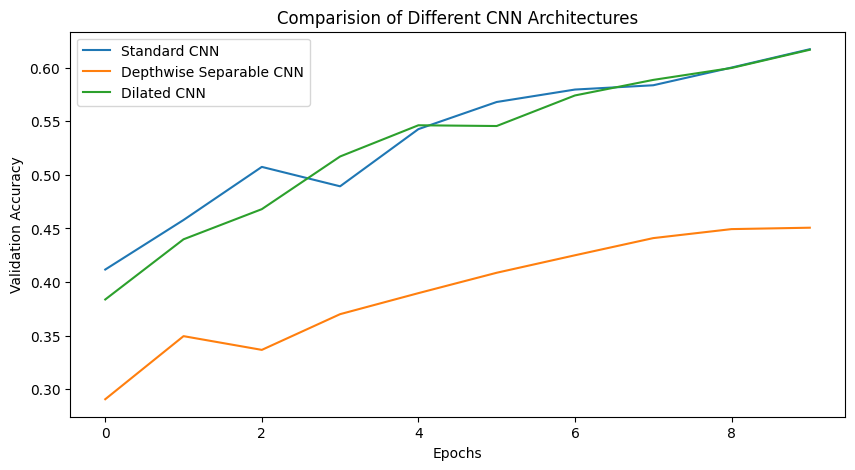

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

def standard_cnn():
  model=models.Sequential([
      layers.Conv2D(32, (3,3), activation='relu',padding='same', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(64, (3,3), activation='relu', padding='same'),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(28, (3,3), activation='relu', padding='same'),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

def depthwise_separable_cnn():
  model=models.Sequential([
      layers.SeparableConv2D(32, (3,3), activation='relu',padding='same', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),
      layers.SeparableConv2D(64, (3,3), activation='relu', padding='same'),
      layers.MaxPooling2D((2,2)),
      layers.SeparableConv2D(28, (3,3), activation='relu', padding='same'),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

def dilated_cnn():
  model=models.Sequential([
      layers.Conv2D(32, (3,3), activation='relu',padding='same', dilation_rate=2, input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(64, (3,3), activation='relu', padding='same', dilation_rate=2),
      layers.MaxPooling2D((2,2)),
      layers.Conv2D(28, (3,3), activation='relu', padding='same', dilation_rate=2),
      layers.GlobalAveragePooling2D(),
      layers.Dense(64, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

def train_and_evaluate(model, name):
  model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  print(f"\n Training {name} model...")
  history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))
  test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
  print(f" {name} Test accuracy: {test_acc : .4f}")
  return history

models_dict= {
      "Standard CNN": standard_cnn(),
      "Depthwise Separable CNN": depthwise_separable_cnn(),
      "Dilated CNN" : dilated_cnn()
}

histories = {}
for name, model in models_dict.items():
    histories[name]=train_and_evaluate(model, name)

plt.figure(figsize=(10,5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title("Comparision of Different CNN Architectures")
plt.show()